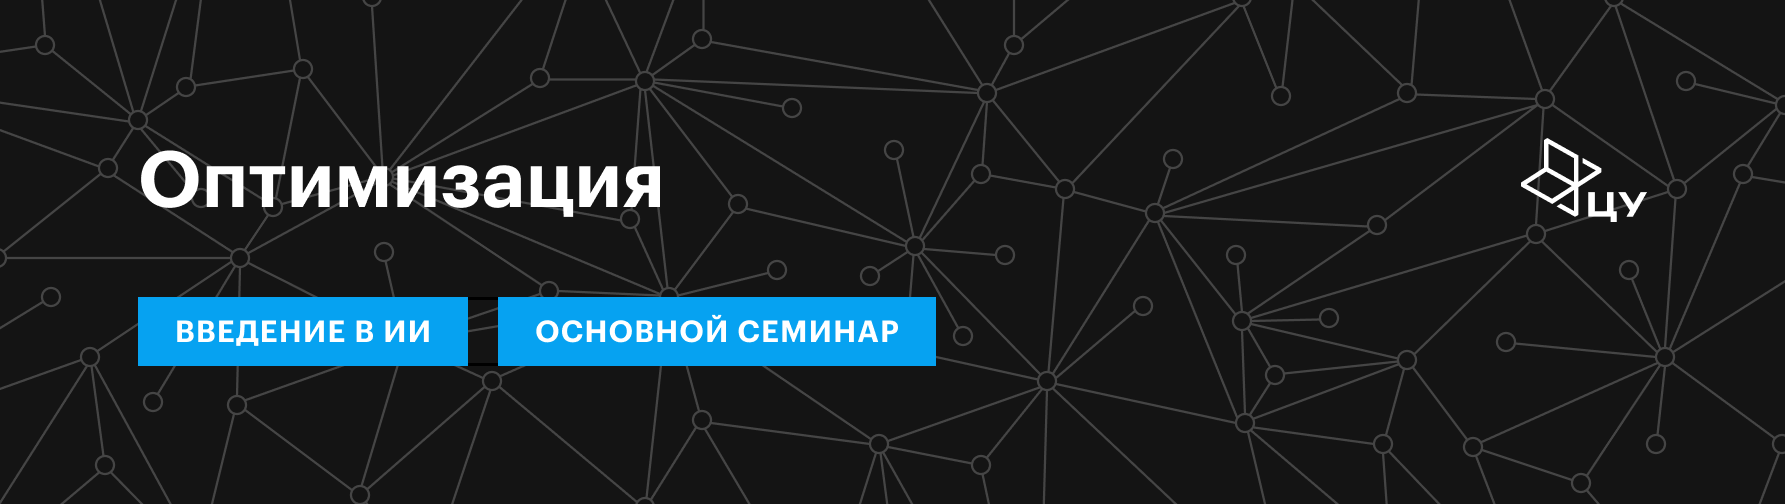

# Семинар по теме «Оптимизация и оценка моделей»

Сегодня мы посмотрим, как обучаются модели машинного обучения, как работает градиентный спуск, и попробуем оценить модели, которые уже строили.

Из этого текста ты узнаешь:
- как устроена простейшая модель машинного обучения,
- как работает градиентный спуск,
- как работает стохастический градиентный спуск,
- как оценивать модели с помощью бутстрапа.

> Если в Jupyter не видны виджеты, запусти ячейку с кодом ниже и проверь корректность установки.

In [ ]:
!pip install ipywidgets

In [ ]:
# --- Импорты и общие настройки ---
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
import pandas as pd
# Для интерактива
import ipywidgets as widgets
from ipywidgets import VBox, HBox, Layout
from IPython.display import display, clear_output
import time

# ML
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier, plot_tree
from sklearn.datasets import make_regression, make_moons
from sklearn.metrics import mean_squared_error, accuracy_score
from sklearn.model_selection import train_test_split

plt.rcParams["figure.figsize"] = (7, 5)
np.set_printoptions(precision=4, suppress=True)

rng = np.random.default_rng(42)


 Сгенерируем игрушечные данные и попробуем построить и обучить на них простейшую модель.

 Пусть у нас есть всего лишь один признак, который достаточно сильно линейно связан с таргетом.


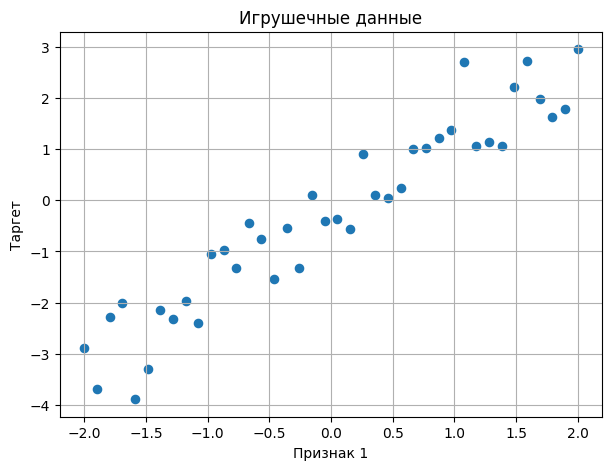

In [ ]:
#  y = a * x + b + шум
n = 40
X = np.linspace(-2, 2, n)
true_w, true_b = 1.4, -0.3
noise = rng.normal(0, 0.7, size=n)
y = true_w * X + true_b + noise

plt.figure()
plt.scatter(X, y, s=35)
plt.title("Игрушечные данные")
plt.xlabel("Признак 1")
plt.ylabel("Таргет") # ТАРГЕТ!!!
plt.grid(True)
plt.show()


## Первая ML-модель

Допустим, мы не знаем, как именно связаны переменные, то есть перед нами просто нарисованный график.

Глядя на него, мы понимаем, что изменение одной переменной в положительную сторону положительно влияет на другую переменную, причём неважно, от какой точки мы сдвигаемся. График не начинает расти быстрее или медленнее при удалении, например, от нуля.

В таком случае можно сделать вывод, что между переменными есть линейная зависимость.


### Задание 1

Как ты думаешь, насколько часто в жизни встречаются зависимости, хорошо аппроксимируемые линейными моделями? Какие есть примеры?

#### ОТВЕТ ДЛЯ СЕМИНАРИСТА

Примеров очень много:

* Доходы и расходы домохозяйства

* Курение и заболеваемость раком лёгких

* Уровень образования и доход

* Плотность населения и стоимость жилья

* Масса звезды и её светимость

- - -

Есть множество формул, описывающих линейную зависимость:

* Скорость, время и расстояние

* Расход топлива и расстояние

* Доход = ставка * часы

* Цена на квартиру и метраж

- - -

### Линейная модель

Получается, одна из самых простых моделей, которую только можно представить, — это комбинация признаков с некоторыми коэффициентами.



**Линейная модель:** $a(x) = \sum_{i} w_i \cdot x_i$ + b,

* где $w_i$ — веса;

* $x_i$ — числовые признаки;

* $b$ — константа, она нужна для того, чтобы график не был зафиксирован в нуле.

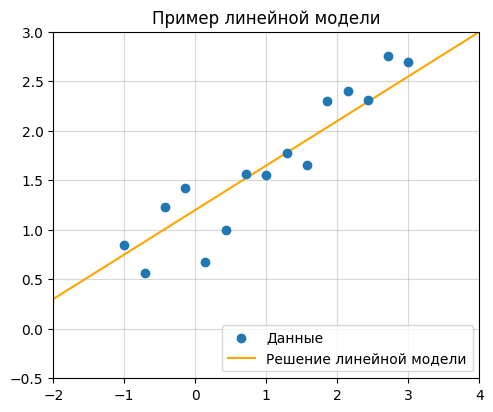

Эта модель называется **линейной регрессией**. На следующей неделе мы подробнее изучим её архитектуру. Пока важно понять, что в ней строится линейная функция над признаками объектов и обучаются коэффициенты при этих признаках.

Теперь попробуем понять, насколько хороша какая-то конкретная модель. Для этого введём функционал качества (Стандартное MSE).

$$
L(x, y, a(x)) = \frac{1}{n} \cdot \sum_{i=1}^{n} \left( y_{pred} - y \right)^2 = \frac{1}{n} \cdot \sum_{i=1}^{n} \left( (\vec{w} \cdot \vec{x}_i) + b - y \right)^2
.$$

$(\vec{w} \cdot \vec{x})$ — скалярное произведение векторов, которое можно рассматривать как короткую запись следующей конструкции: $w_1 x_1+w_2 x_2+..+.w_m x_m = \sum_{i} w_i \cdot x_i$.


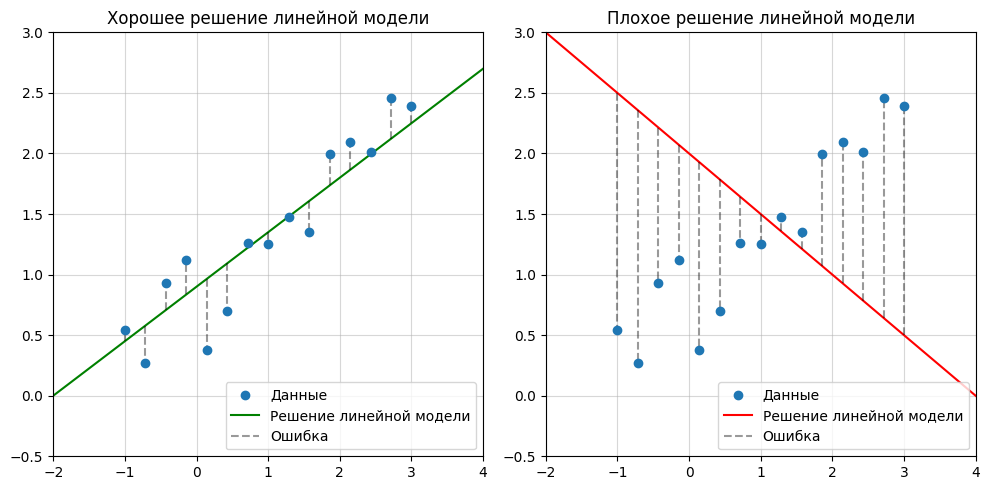

Измеряя ошибку, мы оцениваем, насколько прямая далека от своего наилучшего расположения.

На графике видно, что красная модель хуже зелёной, потому что усреднённая сумма квадратов длин серых палочек (MSE) у красной модели очевидно будет больше, чем у зелёной.

In [ ]:
def predict(X, w, b):
    return w * X + b

def mse_loss(X, y, w, b):
    yhat = predict(X, w, b)
    return np.mean((yhat - y) ** 2)


Чтобы решить задачу, построим модель регрессии. Мы задали функционал ошибки, чтобы иметь возможность сообщать модели, что хорошо, а что плохо. Осталось только получить решение с помощью градиентного спуска.

### Задание 2

Вспомни и запиши этапы градиентного спуска.

#### ОТВЕТ ДЛЯ СЕМИНАРИСТА

1) Выбираем темп обучения `lr`, начальную точку `x0` и функцию потерь `L`.

2) Считаем градиент функции потерь `L` в точке.

3) Делаем шаг `lr * антиградиент`.

4) Повторяем шаги 2 и 3, пока не достигнем максимума операций или пока ошибка не перестанет сильно меняться.



Нам нужно знать производные модели, попробуем их найти по её параметрам.

$$
L(x; y; a(x)) = \frac{1}{n} \cdot \sum_{i=1}^{n} \left( (\vec w \cdot \vec{x}_i) + b - y \right)^2
;$$

$$
\frac{\partial L}{\partial w_1} = \frac{\partial}{\partial w_1} \left( \frac{1}{n} \cdot \sum_{i=1}^{n} \left( (w_1 x_i^1 + b - y)^2 \right) \right) = 2 \cdot \frac{1}{n} \cdot \sum_{i=1}^{n} \left( (w_1 x_i^1 + b - y) \cdot x_i^1 \right)
;$$

$$
\frac{\partial L}{\partial b} = \frac{\partial}{\partial b} \left( \frac{1}{n} \cdot \sum_{i=1}^{n} \left( (w_1 x_i^1 + b - y)^2 \right) \right) = 2 \cdot \frac{1}{n} \cdot \sum_{i=1}^{n} \left( w_1 x_i^1 + b - y \right)
.$$

### Задание 3

Создадим функцию, считающую градиент MSE.

In [ ]:
def grad_mse(X, y, w, b):

    pred = # Предсказание модели
    err = # Ошибка
    dw = # Компонента по w
    db = # Компонента градиента по b
    return dw, db


#### ОТВЕТ ДЛЯ СЕМИНАРИСТА

In [ ]:
def grad_mse(X, y, w, b):
    pred = predict(X, w, b)
    err = (pred - y)
    dw = 2.0 * np.mean(err * X)
    db = 2.0 * np.mean(err)
    return dw, db


## Градиентный спуск в действии


Для лучшего понимания и более элегантной визуализации графика функции двух переменных используют линии уровня.

> **Линия уровня C функции $f(x,y)$** — это множество точек $(x,y)$ на плоскости, таких, что $f(x,y) = C$.

Если ты помнишь школьную географию, это аналог контурной карты высот.

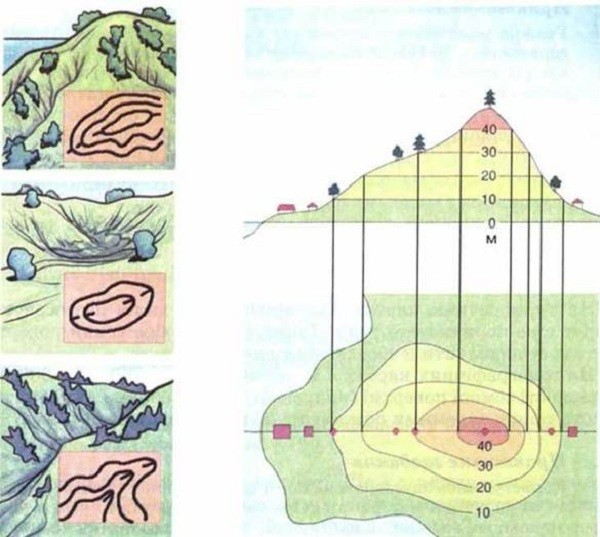

In [ ]:
# @title Визуализация градиентного спуска (служебный код)


# --- Вспомогательный расчёт сетки для поверхности ошибки ---
def loss_grid(X, y, w_range=(-3, 3), b_range=(-3, 3), steps=121):
    ws = np.linspace(w_range[0], w_range[1], steps)
    bs = np.linspace(b_range[0], b_range[1], steps)
    W, B = np.meshgrid(ws, bs)
    Z = np.zeros_like(W)
    for i in range(W.shape[0]):
        for j in range(W.shape[1]):
            Z[i, j] = mse_loss(X, y, W[i, j], B[i, j])
    return ws, bs, W, B, Z

ws, bs, W, B, Z = loss_grid(X, y, w_range=(-3, 3), b_range=(-3, 3), steps=30)
Zmin, Zmax = float(Z.min()), float(Z.max())


state = {"w": -2.5, "b": -2.5, "path": [(-2.5, -2.5)]}
history = [(state["w"], state["b"], mse_loss(X, y, state["w"], state["b"]))]
losses = [mse_loss(X, y, state["w"], state["b"])]

w_slider = widgets.FloatSlider(value=-2.5, min=-3, max=3, step=0.05, description="w", continuous_update=False)
b_slider = widgets.FloatSlider(value=-2.5, min=-3, max=3, step=0.05, description="b", continuous_update=False)
lr_slider = widgets.FloatLogSlider(value=0.1, base=10, min=-3, max=0, step=0.05, description="lr")

step_btn = widgets.Button(description="Сделать 1 шаг GD", button_style="primary")
reset_btn = widgets.Button(description="Сброс", button_style="warning")

out = widgets.Output()

def draw(w, b, lr):
    with out:
        clear_output(wait=True)
        loss = mse_loss(X, y, w, b)
        dw, db = grad_mse(X, y, w, b)

        fig = plt.figure(figsize=(10, 8))

        ax1 = fig.add_subplot(2, 2, 1)
        ax2 = fig.add_subplot(2, 2, 2, projection='3d')
        ax3 = fig.add_subplot(2, 2, 3)
        ax4 = fig.add_subplot(2, 2, 4)

        vmin, vmax = Z.min(), Z.max()

        #=[AX1]============================================================

        cs = ax1.contourf(W, B, Z, cmap="viridis", vmin=vmin, vmax=vmax, levels=30, zorder=20)
        cs = ax1.contour(W, B, Z, colors='black', alpha=0.3, levels=30, zorder=30)
        ax1.set_xlim(W[0,0], W[-1,-1])
        ax1.set_ylim(B[0,0], B[-1,-1])

        # Рисуем траекторию
        xs = [h[0] for h in history]
        ys = [h[1] for h in history]
        ax1.plot(xs, ys, color="orange", zorder=110)

        ax1.scatter([w], [b], s=80, marker="o", color="tab:orange", zorder=120, label="Линии уровней")
        ax1.set_title(f"Поверхность ошибки (2D контуры MSE)")
        ax1.set_xlabel("w")
        ax1.set_ylabel("b", labelpad=-7)

        # scale = -0.25
        ax1.arrow(w, b, -dw, -db, head_width=0.08, color="black", alpha=0.25, length_includes_head=True, zorder=98)
        ax1.arrow(w, b, -lr*dw, -lr*db, head_width=0.08, length_includes_head=True, zorder=99)

        #=[AX2]============================================================

        stride = 3
        Wd = W[::stride, ::stride]
        Bd = B[::stride, ::stride]
        Zd = Z[::stride, ::stride]

        ax2.plot_surface(Wd, Bd, Zd, rstride=1, cstride=1, linewidth=0.2, edgecolor='black', cmap="viridis", vmin=vmin, vmax=vmax, antialiased=True, alpha=0.85)

        ax2.set_title("3D поверхность ошибки (MSE)")
        ax2.set_xlabel("w", labelpad=-15)
        ax2.set_ylabel("b", labelpad=-15)

        # Рисуем траекторию
        xs = [h[0] for h in history]
        ys = [h[1] for h in history]
        zs = [h[2] for h in history]
        ax2.plot(xs, ys, zs, color="orange", zorder=110)

        # ТЕКУЩАЯ ТОЧКА
        ax2.plot(w, b, loss, 'o', markersize=6, color='orange', zorder=10)

        # ГРАДИЕНТ
        ax2.plot([w, w], [b, b], [loss, 0], 'k--')
        ax2.quiver(w, b, 0, - lr * dw, - lr * db, 0, color="black")

        #=[AX3]============================================================

        x_losses = np.arange(1, len(losses) + 1)

        # Создаём сегменты линии
        points = np.array([x_losses, losses]).T.reshape(-1, 1, 2)
        segments = np.concatenate([points[:-1], points[1:]], axis=1)

        # Создаём LineCollection с разными цветами для сегментов
        norm = plt.Normalize(min(losses), max(losses))
        lc = LineCollection(segments, cmap='viridis')
        lc.set_clim(vmin=vmin, vmax=vmax)
        lc.set_array(losses)  # Цвет зависит от y
        lc.set_linewidth(2)

        ax3.add_collection(lc)

        #ax3.plot(list(range(1, len(losses) + 1)), losses)
        #ax3.plot(x_losses, losses)
        ax3.set_xlim(0, max(len(losses) + 1, 11))
        ax3.set_ylim(vmin, vmax)
        ax3.set_xticks(list(range(1, max(len(losses) + 1, 11))))
        ax3.grid(True)
        ax3.set_title("Значение функции потерь (MSE)")
        ax3.scatter(x_losses, losses, c=losses, cmap='viridis', vmin=vmin, vmax=vmax, s=50, zorder=20)

        #=[AX4]============================================================

        ax4.scatter(X, y, s=35, label="Данные", zorder=20)
        xs = np.array([X.min(), X.max()])
        ax4.plot(xs, predict(xs, w, b), linewidth=2, label="Решение модели", color="tab:orange", zorder=30)
        ax4.set_xlim(xs[0], xs[1])
        ax4.set_ylim(-4, 4)
        ax4.set_title("Линейная модель")
        ax4.set_xlabel("x")
        ax4.set_ylabel("y")
        ax4.grid(True)
        ax4.legend(loc="upper left")

        y_pred = X * w + b

        ax4.vlines(X, y_pred, y, colors='black', alpha=0.3, linestyles='dashed', label="Ошибка",zorder=10)

        plt.tight_layout()

        plt.show()

def sync_from_sliders(_=None):
    state["w"] = w_slider.value
    state["b"] = b_slider.value
    draw(state["w"], state["b"], lr_slider.value)

def on_step(_):
    global losses
    global history

    for s in (w_slider, b_slider):
          s.unobserve_all()

    w = w_slider.value
    b = b_slider.value
    lr = lr_slider.value
    dw, db = grad_mse(X, y, w, b)
    w_new = float(w - lr * dw)
    b_new = float(b - lr * db)

    w_new = max(w_slider.min, min(w_slider.max, w_new))
    b_new = max(b_slider.min, min(b_slider.max, b_new))
    losses.append(mse_loss(X, y, w_new, b_new))

    w_slider.value = w_new
    b_slider.value = b_new

    # Добавляем новую точку в путь
    state["path"].append((w_new, b_new))
    history.append((w_new, b_new, mse_loss(X, y, w_new, b_new)))

    for s in (w_slider, b_slider):
        s.observe(sync_from_sliders, names='value')

    draw(w_new, b_new, lr_slider.value)

def on_reset(_):
    global losses
    global history

    for s in (w_slider, b_slider):
          s.unobserve_all()

    w_slider.value = -2.5
    b_slider.value = -2.5
    state["path"] = [(-2.5, -2.5)]
    losses = [mse_loss(X, y, -2.5, -2.5)]
    history = [(-2.5, -2.5, mse_loss(X, y, -2.5, -2.5))]

    for s in (w_slider, b_slider):
        s.observe(sync_from_sliders, names='value')

    draw(-2.5, -2.5, lr_slider.value)

for s in (w_slider, b_slider, lr_slider):
    s.observe(sync_from_sliders, names="value")

step_btn.on_click(on_step)
reset_btn.on_click(on_reset)

ui = VBox([
    HBox([w_slider, b_slider, lr_slider]),
    HBox([step_btn, reset_btn]),
    out
])

display(ui)
sync_from_sliders()

TypeError: mse_loss() missing 1 required positional argument: 'b'

### Задание 4



Чем SGD отличается от обычного градиентного спуска?

#### ОТВЕТ ДЛЯ СЕМИНАРИСТА

Градиентный спуск (GD) считает ошибку по всей выборке сразу, а стохастический (SGD) — только по одному объекту или по какому-то фиксированному их количеству.

### Обучение линейной модели

Необходимо обучить линейную модель вида $y = w_1 x+b$.

**Дано:**

* датасет: `[0,1] [1,1] [2,1] [3,2]`;

* `lr = 0.2`;

* начальная модель: $y = 0x+0$.

1) Сделать 1 шаг GD.
2) Сделать 1 шаг SGD.



**Решение**

Шаг 1.

Формулы для градиентов были посчитаны выше:

$$
\frac{\partial L}{\partial w_1} = \frac{2}{4} ((-1 \cdot 0) +(-1 \cdot 1) +(-1 \cdot 2) +(-2 \cdot 3)) = - \frac{9}{4}
;$$

$$
\frac{\partial L}{\partial b} = \frac{2}{4} ((-1) +(-1) +(-1) +(-2)) = - \frac{5}{2}
.$$

Следовательно, так как шагаем по антиградиенту, линейная модель после первого шага GD:

$$y = \frac{9}{4} \cdot 0,2 \cdot x + \frac{5}{2} \cdot  0,2 = 0,45x+ 0,5.$$

Шаг 2.

Теперь будем считать градиенты не по всей выборке, а только по её части. Например, будем брать 25%, то есть один объект.

Возьмём случайную первую точку — `[0,1]`, посчитаем градиент.

$$
\frac{\partial L}{\partial w_1} = \frac{2}{1} (0) = 0
;$$

$$
\frac{\partial L}{\partial b} = \frac{2}{1} (-1) = -2
.$$

Так как шагаем по антиградиенту, линейная модель после первого шага SGD:

$$y = 0 \cdot 0,2 \cdot x+ 2 \cdot  0,2 = 0x+ 0,4.$$


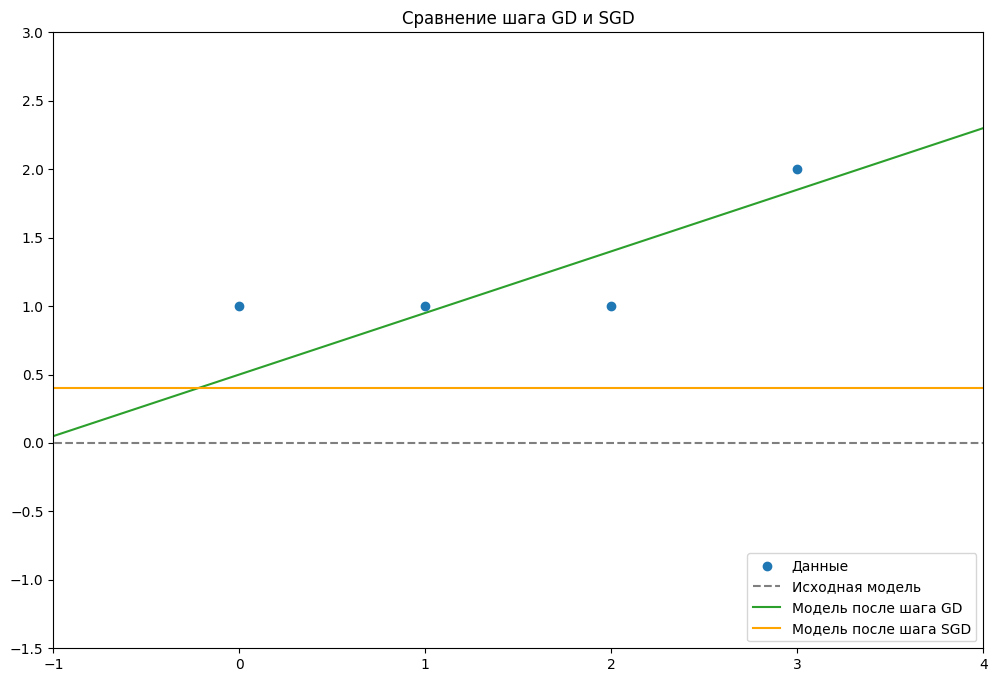

### Задание 5



Чем отличается траектория SGD от обычного градиентного спуска? Какие у неё преимущества и недостатки?

#### ОТВЕТ ДЛЯ СЕМИНАРИСТА

Так как у нас достаточно мало выбросов, каждый объект с большой вероятностью будет полезен, а траектория будет вычисляться гораздо быстрее. При этом есть и минус - траектория может стать слишком хаотичной.

## SGD и GD

Теперь посмотрим, как происходит обучение линейной модели улучшенными алгоритмами градиентного спуска.

- **Обычный GD**: градиент по всему датасету — шаги стабильные, но каждый шаг «дорогой».
- **SGD**: градиент по одному объекту или по батчу (набору объектов) — шаги более «шумные», но дешёвые, часто быстрее добирается к хорошей области.


In [ ]:
# @title SGD  (служебный код)
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
import ipywidgets as widgets
from ipywidgets import HBox, VBox
from IPython.display import display, clear_output


def predict(x, w, b):
    return w * x + b

def mse_loss(X, y, w, b):
    y_pred = predict(X, w, b)
    return float(np.mean((y_pred - y) ** 2))

def grad_mse(X, y, w, b):
    err = (w * X + b - y)
    dw = float(2.0 * np.mean(err * X))
    db = float(2.0 * np.mean(err))
    return dw, db


W_MIN, W_MAX = -3.0, 3.0
B_MIN, B_MAX = -3.0, 3.0

def build_surface(X, y, wmin=W_MIN, wmax=W_MAX, bmin=B_MIN, bmax=B_MAX, grid_n=70):
    ws = np.linspace(wmin, wmax, grid_n)
    bs = np.linspace(bmin, bmax, grid_n)
    W, B = np.meshgrid(ws, bs)

    pred = X[:, None, None] * W[None, :, :] + B[None, :, :]
    Z = np.mean((pred - y[:, None, None]) ** 2, axis=0)
    return W, B, Z


state = {"w": -2.5, "b": -2.5}
history = [(state["w"], state["b"], mse_loss(X, y, state["w"], state["b"]))]
losses  = [history[0][2]]

W, B, Z = build_surface(X, y, grid_n=70)
vmin, vmax = float(Z.min()), float(Z.max())

# Widgets

w_slider = widgets.FloatSlider(value=state["w"], min=W_MIN, max=W_MAX, step=0.05, description="w", continuous_update=False)
b_slider = widgets.FloatSlider(value=state["b"], min=B_MIN, max=B_MAX, step=0.05, description="b", continuous_update=False)
lr_slider = widgets.FloatLogSlider(value=0.1, base=10, min=-3, max=0, step=0.05, description="lr")

mode_dd = widgets.Dropdown(options=[("GD", "GD"), ("SGD", "SGD")], value="SGD", description="mode")
batch_slider = widgets.IntSlider(value=3, min=1, max=256, step=1, description="batch", continuous_update=False)

step_btn  = widgets.Button(description="Сделать 1 шаг", button_style="primary")
reset_btn = widgets.Button(description="Сброс", button_style="warning")

out = widgets.Output()
rng = np.random.default_rng(42)


def draw(w, b, lr, mode, batch_size):
    with out:
        clear_output(wait=True)

        loss = mse_loss(X, y, w, b)
        dw_full, db_full = grad_mse(X, y, w, b)

        fig = plt.figure(figsize=(10, 8))
        ax1 = fig.add_subplot(2, 2, 1)
        ax2 = fig.add_subplot(2, 2, 2, projection="3d")
        ax3 = fig.add_subplot(2, 2, 3)
        ax4 = fig.add_subplot(2, 2, 4)

        # ========== AX1: 2D-контуры ==========
        ax1.contourf(W, B, Z, cmap="viridis", vmin=vmin, vmax=vmax, levels=20)
        ax1.contour(W, B, Z, colors="black", alpha=0.3, levels=20)

        xs = [h[0] for h in history]
        ys = [h[1] for h in history]
        ax1.plot(xs, ys, color="orange", zorder=110)
        ax1.scatter([w], [b], s=80, marker="o", color="tab:orange", zorder=120)

        ax1.set_xlim(W_MIN, W_MAX)
        ax1.set_ylim(B_MIN, B_MAX)
        ax1.set_title("Поверхность ошибки (2D контуры MSE)")
        ax1.set_xlabel("w")
        ax1.set_ylabel("b", labelpad=-7)

        ax1.arrow(w, b, -dw_full, -db_full, head_width=0.08, color="black",
                  alpha=0.25, length_includes_head=True, zorder=98)
        ax1.arrow(w, b, -lr * dw_full, -lr * db_full, head_width=0.08,
                  length_includes_head=True, zorder=99)

        # ========== AX2: 3D-поверхность
        surface_stride = 7
        Wd = W[::surface_stride, ::surface_stride]
        Bd = B[::surface_stride, ::surface_stride]
        Zd = Z[::surface_stride, ::surface_stride]

        ax2.plot_surface(
            Wd, Bd, Zd,
            rstride=1, cstride=1,
            linewidth=0.05, edgecolor="black",
            cmap="viridis", vmin=vmin, vmax=vmax,
            antialiased=False, alpha=0.85
        )

        ax2.set_title("3D поверхность ошибки (MSE)")
        ax2.set_xlabel("w", labelpad=-15)
        ax2.set_ylabel("b", labelpad=-15)

        zs = [h[2] for h in history]
        ax2.plot(xs, ys, zs, color="orange", linewidth=2)

        # Вертикальная «проекция»
        ax2.plot([w, w], [b, b], [loss, 0], "k--", alpha=0.6)

        # Антигадиент
        ax2.quiver(w, b, 0, -lr * dw_full, -lr * db_full, 0,
                   color="black", length=1.0, normalize=False)


        # Текущая точка

        # Рисуем траекторию
        xs = [h[0] for h in history]
        ys = [h[1] for h in history]
        zs = [h[2] for h in history]
        ax2.plot(xs, ys, zs, color="orange", zorder=110)
        eps = 5
        z_point = loss

        ax2.plot(w, b, loss, 'o', markersize=6, color='orange', zorder=10)

        # ========== AX3: loss по шагам ==========
        x_losses = np.arange(1, len(losses) + 1)
        points = np.array([x_losses, losses]).T.reshape(-1, 1, 2)
        if len(points) >= 2:
            segments = np.concatenate([points[:-1], points[1:]], axis=1)
            lc = LineCollection(segments, cmap="viridis")
            lc.set_clim(vmin=vmin, vmax=vmax)
            lc.set_array(np.array(losses[:-1], dtype=float))
            lc.set_linewidth(2)
            ax3.add_collection(lc)

        ax3.scatter(x_losses, losses, c=losses, cmap="viridis",
                    vmin=vmin, vmax=vmax, s=50, zorder=20)
        ax3.set_xlim(0, max(len(losses) + 1, 11))
        ax3.set_ylim(vmin, vmax)
        ax3.set_xticks(list(range(1, max(len(losses) + 1, 11))))
        ax3.grid(True)
        ax3.set_title(f"Значение функции потерь (MSE) | mode={mode}")

        # ========== AX4: данные + текущая прямая ==========
        ax4.scatter(X, y, s=35, label="Данные", zorder=20)
        xs_line = np.array([X.min(), X.max()])
        ax4.plot(xs_line, predict(xs_line, w, b), linewidth=2,
                 label="Решение модели", color="tab:orange", zorder=30)

        ax4.set_xlim(xs_line[0], xs_line[1])
        ax4.set_ylim(-4, 4)
        ax4.set_title("Линейная модель")
        ax4.set_xlabel("x")
        ax4.set_ylabel("y")
        ax4.grid(True)
        ax4.legend(loc="upper left")

        y_pred = predict(X, w, b)
        ax4.vlines(X, y_pred, y, colors="black", alpha=0.3,
                   linestyles="dashed", zorder=10)

        plt.tight_layout()
        plt.show()




def sync_from_sliders(_=None):
    state["w"] = w_slider.value
    state["b"] = b_slider.value
    batch_slider.disabled = (mode_dd.value != "SGD")
    draw(state["w"], state["b"], lr_slider.value, mode_dd.value, batch_slider.value)

def on_step(_):
    global losses, history

    for s in (w_slider, b_slider, lr_slider, mode_dd, batch_slider):
        try:
            s.unobserve_all()
        except Exception:
            pass

    w = w_slider.value
    b = b_slider.value
    lr = lr_slider.value
    mode = mode_dd.value
    batch_size = int(batch_slider.value)

    if mode == "GD":
        Xb, yb = X, y
    else:  # "SGD"
        n = len(X)
        bs = min(batch_size, n)
        idx = rng.choice(n, size=bs, replace=False)
        Xb, yb = X[idx], y[idx]

    dw, db = grad_mse(Xb, yb, w, b)

    w_new = float(w - lr * dw)
    b_new = float(b - lr * db)

    w_new = max(w_slider.min, min(w_slider.max, w_new))
    b_new = max(b_slider.min, min(b_slider.max, b_new))

    full_loss = mse_loss(X, y, w_new, b_new)
    losses.append(full_loss)
    history.append((w_new, b_new, full_loss))

    w_slider.value = w_new
    b_slider.value = b_new

    for s in (w_slider, b_slider, lr_slider, mode_dd, batch_slider):
        s.observe(sync_from_sliders, names="value")

    draw(w_new, b_new, lr, mode, batch_size)

def on_reset(_):
    global losses, history

    for s in (w_slider, b_slider, lr_slider, mode_dd, batch_slider):
        try:
            s.unobserve_all()
        except Exception:
            pass

    w0, b0 = -2.5, -2.5
    w_slider.value = w0
    b_slider.value = b0
    state["w"], state["b"] = w0, b0

    l0 = mse_loss(X, y, w0, b0)
    losses = [l0]
    history = [(w0, b0, l0)]

    for s in (w_slider, b_slider, lr_slider, mode_dd, batch_slider):
        s.observe(sync_from_sliders, names="value")

    sync_from_sliders()

for s in (w_slider, b_slider, lr_slider, mode_dd, batch_slider):
    s.observe(sync_from_sliders, names="value")

step_btn.on_click(on_step)
reset_btn.on_click(on_reset)

ui = VBox([
    HBox([w_slider, b_slider, lr_slider]),
    HBox([mode_dd, batch_slider]),
    HBox([step_btn, reset_btn]),
    out
])

display(ui)
sync_from_sliders()


## Проблемы градиентного спуска

При использовании градиентного спуска могут возникнуть сложности, которые влияют на процесс обучения модели.

### Локальные минимумы

Иногда градиентный спуск застревает в локальных минимумах и не находит глобальные.

In [ ]:
# @title Локальные минимумы (служебный код)

import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from ipywidgets import HBox, VBox
from IPython.display import display, clear_output

LEVELS = [-350,-300,-250,-225,-150,-100, 0,25,50,75,100,125,150,175, 180,200,250,300,500,600,800,1300]

def f(x, y):
    return (x**2 + y - 11)**2 + (x + y**2 - 7)**2 - 0.5*(x**2 - y - 1)**2

grad_f = None

X_MIN, X_MAX = -6.0, 6.0
Y_MIN, Y_MAX = -5.0, 5.0
GRID_N = 140

def numeric_grad(fun, x, y, eps=1e-4):
    fx1 = fun(x + eps, y)
    fx2 = fun(x - eps, y)
    fy1 = fun(x, y + eps)
    fy2 = fun(x, y - eps)
    return (fx1 - fx2) / (2 * eps), (fy1 - fy2) / (2 * eps)

def get_grad(x, y):
    if callable(grad_f):
        return grad_f(x, y)
    return numeric_grad(f, x, y)

def safe_eval_on_grid(fun, W, B):
    try:
        Z = fun(W, B)
        Z = np.asarray(Z)
        if Z.shape != W.shape:
            raise ValueError("f(W,B) вернуло массив неправильной формы")
        return Z
    except Exception:
        vf = np.vectorize(fun)
        return vf(W, B)

def _validate_levels(levels):
    levels = np.asarray(levels, dtype=float).ravel()
    levels = np.unique(levels)
    if levels.size < 2:
        raise ValueError("LEVELS должен содержать минимум 2 разных значения.")
    levels = np.sort(levels)
    return levels

LEVELS = _validate_levels(LEVELS)

xs = np.linspace(X_MIN, X_MAX, GRID_N)
ys = np.linspace(Y_MIN, Y_MAX, GRID_N)
W, B = np.meshgrid(xs, ys)
Z = safe_eval_on_grid(f, W, B)

CMAP = "viridis"
POINT_COLOR = "tab:orange"
TRAJ_COLOR = "orange"
vmin, vmax = float(np.min(LEVELS)), float(np.max(LEVELS))

lr_slider = widgets.FloatLogSlider(value=0.01, base=10, min=-4, max=0, step=0.05, description="lr")
x0_slider = widgets.FloatSlider(value=-2.5, min=X_MIN, max=X_MAX, step=0.05, description="x0", continuous_update=False)
y0_slider = widgets.FloatSlider(value= 2.0, min=Y_MIN, max=Y_MAX, step=0.05, description="y0", continuous_update=False)

step_btn  = widgets.Button(description="1 шаг", button_style="primary")
reset_btn = widgets.Button(description="Сброс", button_style="warning")

out = widgets.Output()

sim = {
    "x": float(x0_slider.value),
    "y": float(y0_slider.value),
    "t": 0,
    "traj": np.array([[float(x0_slider.value), float(y0_slider.value)]], dtype=float),
}

def reset_sim():
    global x0_slider
    global y0_slider

    sim["x"] = float(-2.5)
    sim["y"] = float(2.0)
    x0_slider.value = sim["x"]
    y0_slider.value = sim["y"]
    sim["t"] = 0
    sim["traj"] = np.array([[sim["x"], sim["y"]]], dtype=float)

def step_once():
    lr = float(lr_slider.value)
    x, y = float(sim["x"]), float(sim["y"])
    dx, dy = get_grad(x, y)

    x_new = x - lr * float(dx)
    y_new = y - lr * float(dy)

    x_new = max(X_MIN, min(X_MAX, x_new))
    y_new = max(Y_MIN, min(Y_MAX, y_new))

    sim["x"], sim["y"] = x_new, y_new
    sim["t"] += 1
    sim["traj"] = np.vstack([sim["traj"], [x_new, y_new]])

def draw_current():
    traj = sim["traj"]
    t = sim["t"]
    x, y = float(sim["x"]), float(sim["y"])
    lr = float(lr_slider.value)
    val = float(f(x, y))

    with out:
        clear_output(wait=True)

        fig = plt.figure(figsize=(10, 6))
        ax = fig.add_subplot(1, 1, 1)

        ax.contourf(W, B, Z, levels=LEVELS, cmap=CMAP, vmin=vmin, vmax=vmax)
        ax.contour(W, B, Z, levels=LEVELS, colors="black", alpha=0.25, linewidths=0.8)

        ax.plot(traj[:, 0], traj[:, 1], linewidth=2, color=TRAJ_COLOR, zorder=15)
        ax.scatter([x], [y], s=60, color=POINT_COLOR, zorder=20)


        dx, dy = get_grad(x, y)

        step_dx = -lr * float(dx)
        step_dy = -lr * float(dy)

        vis = 1.0

        ax.arrow(
            x, y, vis * step_dx, vis * step_dy,
            head_width=0.18,
            length_includes_head=True,
            color="black",
            alpha=0.6,
            zorder=25
        )

        ax.set_title(f"GD на f(x,y): шаг {t}\nf(x,y)={val:.4g}")
        ax.set_xlabel("x")
        ax.set_ylabel("y")
        ax.set_xlim(X_MIN, X_MAX)
        ax.set_ylim(Y_MIN, Y_MAX)
        ax.grid(True)

        plt.show()
        print(f"x={x:.4f}, y={y:.4f}, f={val:.6g}, lr={lr:.4g}")

def on_reset(_):
    reset_sim()
    draw_current()

def on_step(_):
    step_once()
    draw_current()

def on_params_change(_=None):
    sim["x"], sim["y"] = float(x0_slider.value), float(y0_slider.value)
    sim["t"] += 1
    sim["traj"] = np.array([[sim["x"], sim["y"]]], dtype=float)
    draw_current()

step_btn.on_click(on_step)
reset_btn.on_click(on_reset)

for w in (lr_slider, x0_slider, y0_slider):
    w.observe(on_params_change, names="value")

controls = VBox([lr_slider, x0_slider, y0_slider, HBox([step_btn, reset_btn])])
ui = VBox([controls, out])

display(ui)
reset_sim()
draw_current()


### Выбор lr

Теперь сделаем значение `lr` немного больше и посмотрим, к чему это приведёт.

In [ ]:
# @title Выбор LR (служебный код)
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from ipywidgets import HBox, VBox
from IPython.display import display, clear_output

LEVELS = [-350,-300,-250,-225,-150,-100, 0,25,50,75,100,125,150,175, 180,200,250,300,500,600,800,1300]

def f(x, y):
    return (x**2 + y - 11)**2 + (x + y**2 - 7)**2 - 0.5*(x**2 - y - 1)**2

grad_f = None

X_MIN, X_MAX = -6.0, 6.0
Y_MIN, Y_MAX = -5.0, 5.0
GRID_N = 140

def numeric_grad(fun, x, y, eps=1e-4):
    fx1 = fun(x + eps, y)
    fx2 = fun(x - eps, y)
    fy1 = fun(x, y + eps)
    fy2 = fun(x, y - eps)
    return (fx1 - fx2) / (2 * eps), (fy1 - fy2) / (2 * eps)

def get_grad(x, y):
    if callable(grad_f):
        return grad_f(x, y)
    return numeric_grad(f, x, y)

def safe_eval_on_grid(fun, W, B):
    try:
        Z = fun(W, B)
        Z = np.asarray(Z)
        if Z.shape != W.shape:
            raise ValueError("f(W,B) вернуло массив неправильной формы")
        return Z
    except Exception:
        vf = np.vectorize(fun)
        return vf(W, B)

def _validate_levels(levels):
    levels = np.asarray(levels, dtype=float).ravel()
    levels = np.unique(levels)
    if levels.size < 2:
        raise ValueError("LEVELS должен содержать минимум 2 разных значения.")
    levels = np.sort(levels)
    return levels

LEVELS = _validate_levels(LEVELS)

xs = np.linspace(X_MIN, X_MAX, GRID_N)
ys = np.linspace(Y_MIN, Y_MAX, GRID_N)
W, B = np.meshgrid(xs, ys)
Z = safe_eval_on_grid(f, W, B)

CMAP = "viridis"
POINT_COLOR = "tab:orange"
TRAJ_COLOR = "orange"
vmin, vmax = float(np.min(LEVELS)), float(np.max(LEVELS))

lr_slider = widgets.FloatLogSlider(value=0.05, base=10, min=-4, max=0, step=0.05, description="lr")
x0_slider = widgets.FloatSlider(value=-2.5, min=X_MIN, max=X_MAX, step=0.05, description="x0", continuous_update=False)
y0_slider = widgets.FloatSlider(value= 2.0, min=Y_MIN, max=Y_MAX, step=0.05, description="y0", continuous_update=False)

step_btn  = widgets.Button(description="1 шаг", button_style="primary")
reset_btn = widgets.Button(description="Сброс", button_style="warning")

out = widgets.Output()

sim = {
    "x": float(x0_slider.value),
    "y": float(y0_slider.value),
    "t": 0,
    "traj": np.array([[float(x0_slider.value), float(y0_slider.value)]], dtype=float),
}

def reset_sim():
    x0_slider.value = -2.5
    y0_slider.value = 2.0
    sim["x"] = float(x0_slider.value)
    sim["y"] = float(y0_slider.value)
    sim["t"] = 0
    sim["traj"] = np.array([[sim["x"], sim["y"]]], dtype=float)

def step_once():
    lr = float(lr_slider.value)
    x, y = float(sim["x"]), float(sim["y"])
    dx, dy = get_grad(x, y)

    x_new = x - lr * float(dx)
    y_new = y - lr * float(dy)

    x_new = max(X_MIN, min(X_MAX, x_new))
    y_new = max(Y_MIN, min(Y_MAX, y_new))

    sim["x"], sim["y"] = x_new, y_new
    sim["t"] += 1
    sim["traj"] = np.vstack([sim["traj"], [x_new, y_new]])

def draw_current():
    traj = sim["traj"]
    t = sim["t"]
    x, y = float(sim["x"]), float(sim["y"])
    lr = float(lr_slider.value)
    val = float(f(x, y))

    with out:
        clear_output(wait=True)

        fig = plt.figure(figsize=(10, 6))
        ax = fig.add_subplot(1, 1, 1)

        ax.contourf(W, B, Z, levels=LEVELS, cmap=CMAP, vmin=vmin, vmax=vmax)
        ax.contour(W, B, Z, levels=LEVELS, colors="black", alpha=0.25, linewidths=0.8)

        ax.plot(traj[:, 0], traj[:, 1], linewidth=2, color=TRAJ_COLOR, zorder=15)
        ax.scatter([x], [y], s=60, color=POINT_COLOR, zorder=20)

        dx, dy = get_grad(x, y)

        step_dx = -lr * float(dx)
        step_dy = -lr * float(dy)

        vis = 1.0

        ax.arrow(
            x, y, vis * step_dx, vis * step_dy,
            head_width=0.18,
            length_includes_head=True,
            color="black",
            alpha=0.6,
            zorder=25
        )

        ax.set_title(f"GD на f(x,y): шаг {t}\nf(x,y)={val:.4g}")
        ax.set_xlabel("x")
        ax.set_ylabel("y")
        ax.set_xlim(X_MIN, X_MAX)
        ax.set_ylim(Y_MIN, Y_MAX)
        ax.grid(True)

        plt.show()
        print(f"x={x:.4f}, y={y:.4f}, f={val:.6g}, lr={lr:.4g}")

def on_reset(_):
    reset_sim()
    draw_current()

def on_step(_):
    step_once()
    draw_current()

def on_params_change(_=None):
    sim["x"], sim["y"] = float(x0_slider.value), float(y0_slider.value)
    sim["t"] += 1
    sim["traj"] = np.array([[sim["x"], sim["y"]]], dtype=float)
    draw_current()

step_btn.on_click(on_step)
reset_btn.on_click(on_reset)

for w in (lr_slider, x0_slider, y0_slider):
    w.observe(on_params_change, names="value")

controls = VBox([lr_slider, x0_slider, y0_slider, HBox([step_btn, reset_btn])])
ui = VBox([controls, out])

display(ui)
reset_sim()
draw_current()


### Плато

Теперь удостоверимся, что длинные плоские поверхности мешают найти минимум.

In [ ]:
# @title Плато (служебный код)
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from ipywidgets import HBox, VBox
from IPython.display import display, clear_output

def f(x, y):
    return 1 - 1.1 ** (-((x**2 + y**2)**2))

grad_f = None

X_MIN, X_MAX = -6.0, 6.0
Y_MIN, Y_MAX = -6.0, 6.0
GRID_N = 100
ELEV_DEFAULT = 10
AZIM_DEFAULT = 30

def numeric_grad(fun, x, y, eps=1e-4):
    fx1 = fun(x + eps, y)
    fx2 = fun(x - eps, y)
    fy1 = fun(x, y + eps)
    fy2 = fun(x, y - eps)
    return (fx1 - fx2) / (2 * eps), (fy1 - fy2) / (2 * eps)

def get_grad(x, y):
    if callable(grad_f):
        return grad_f(x, y)
    return numeric_grad(f, x, y)

def safe_eval_on_grid(fun, W, B):
    try:
        Z = fun(W, B)
        Z = np.asarray(Z)
        if Z.shape != W.shape:
            raise ValueError("f(W,B) вернуло массив неправильной формы")
        return Z
    except Exception:
        vf = np.vectorize(fun)
        return vf(W, B)

# Grid
xs = np.linspace(X_MIN, X_MAX, GRID_N)
ys = np.linspace(Y_MIN, Y_MAX, GRID_N)
W, B = np.meshgrid(xs, ys)
Z = safe_eval_on_grid(f, W, B)

# Widgets
lr_slider = widgets.FloatLogSlider(value=1, base=10, min=-4, max=0, step=0.05, description="lr")
steps_slider = widgets.IntSlider(value=80, min=5, max=500, step=5, description="max steps")
x0_slider = widgets.FloatSlider(value=-2.5, min=X_MIN, max=X_MAX, step=0.05, description="x0", continuous_update=False)
y0_slider = widgets.FloatSlider(value=2.0, min=Y_MIN, max=Y_MAX, step=0.05, description="y0", continuous_update=False)

step_btn = widgets.Button(description="Сделать 1 шаг", button_style="primary")
reset_btn = widgets.Button(description="Сброс", button_style="warning")

out = widgets.Output()

POINT_COLOR = "tab:orange"
TRAJ_COLOR = "darkorange"
CMAP = "viridis"

sim = {
    "x": float(x0_slider.value),
    "y": float(y0_slider.value),
    "t": 0,
    "traj": np.array([[float(x0_slider.value), float(y0_slider.value)]], dtype=float),
    "settings": (float(lr_slider.value), int(steps_slider.value))
}

def reset_sim():
    sim["x"] = float(x0_slider.value)
    sim["y"] = float(y0_slider.value)
    sim["t"] = 0
    x0_slider.value = -2.5
    y0_slider.value = 2.0
    sim["traj"] = np.array([[sim["x"], sim["y"]]], dtype=float)
    sim["settings"] = (float(lr_slider.value), int(steps_slider.value))

def step_once():
    lr = float(lr_slider.value)
    max_steps = int(steps_slider.value)
    sim["settings"] = (lr, max_steps)

    if sim["t"] >= max_steps:
        return

    x, y = float(sim["x"]), float(sim["y"])
    dx, dy = get_grad(x, y)

    x_new = x - lr * float(dx)
    y_new = y - lr * float(dy)

    x_new = max(X_MIN, min(X_MAX, x_new))
    y_new = max(Y_MIN, min(Y_MAX, y_new))

    sim["x"], sim["y"] = x_new, y_new
    sim["t"] += 1
    sim["traj"] = np.vstack([sim["traj"], [x_new, y_new]])

def draw_current():
    lr, max_steps = sim["settings"]
    traj = sim["traj"]
    t = sim["t"]
    x, y = float(sim["x"]), float(sim["y"])
    val = float(f(x, y))

    with out:
        clear_output(wait=True)

        fig = plt.figure(figsize=(10, 7))
        ax1 = ax3d = fig.add_subplot(1, 2, 1)
        ax3d = fig.add_subplot(1, 2, 2, projection="3d")

        stride = 5
        Wd = W[::stride, ::stride]
        Bd = B[::stride, ::stride]
        Zd = Z[::stride, ::stride]

        dx, dy = get_grad(x, y)

        vmin, vmax = float(np.nanmin(Z)), float(np.nanmax(Z))

        #====[AX1]===========================================

        ax1.contourf(Wd, Bd, Zd, cmap="viridis", vmin=vmin, vmax=vmax, levels=30, zorder=20)
        ax1.contour(Wd, Bd, Zd, colors='black', alpha=0.3, levels=30, zorder=30)
        ax1.set_xlim(W[0,0], W[-1,-1])
        ax1.set_ylim(B[0,0], B[-1,-1])

        # Рисуем траекторию
        xs = [h[0] for h in history]
        ys = [h[1] for h in history]
        ax1.plot(xs, ys, color="orange", zorder=110)

        ax1.scatter([x], [y], s=80, marker="o", color="tab:orange", zorder=120, label="Линии уровней")
        ax1.set_title(f"Поверхность ошибки (2D контуры MSE)")
        ax1.set_xlabel("w")
        ax1.set_ylabel("b", labelpad=-7)

        ax1.arrow(x, y, -dx, -dy, head_width=0.08, color="black", alpha=0.25, length_includes_head=True, zorder=98)
        ax1.arrow(x, y, -lr*dx, -lr*dy, head_width=0.08, length_includes_head=True, zorder=99)

        #====[AX3D]==========================================

        # Фиксированный угол
        ax3d.view_init(elev=ELEV_DEFAULT, azim=AZIM_DEFAULT)

        ax3d.plot_surface(
            Wd, Bd, Zd,
            rstride=1, cstride=1,
            linewidth=0.15, edgecolor="black",
            cmap=CMAP, vmin=vmin, vmax=vmax,
            antialiased=False, alpha=0.85
        )

        # Антиградиент
        dx, dy = get_grad(x, y)
        step_dx = -lr * float(dx)
        step_dy = -lr * float(dy)

        x2 = max(X_MIN, min(X_MAX, x + step_dx))
        y2 = max(Y_MIN, min(Y_MAX, y + step_dy))
        z2 = float(f(x2, y2))

        ax3d.quiver(
            x, y, val,
            x2 - x, y2 - y, z2 - val,
            color="black",
            length=1.0,
            normalize=False
        )

        ax3d.plot([x, x], [y, y], [val, vmin], "k--", alpha=0.35)

        # Траектория
        z_traj = np.array([f(xx, yy) for xx, yy in traj], dtype=float)
        ax3d.plot(traj[:, 0], traj[:, 1], z_traj, linewidth=2, color=TRAJ_COLOR)

        # Чуть повыше точку, а то не видно
        eps = 0.1
        z_point = val + eps

        ax3d.scatter([x], [y], [z_point], s=600, c=["white"], alpha=0.35, depthshade=False)
        ax3d.scatter(
            [x], [y], [z_point],
            s=160,
            c=[POINT_COLOR],
            edgecolors=["black"],
            linewidths=2.0,
            depthshade=False
        )

        ax3d.set_title(f"GD на f(x,y): шаг {t}/{max_steps} | f={val:.4g}")
        ax3d.set_xlabel("x")
        ax3d.set_ylabel("y")
        ax3d.set_zlabel("f")

        plt.tight_layout()
        plt.show()
        print(f"x={x:.4f}, y={y:.4f}, f={val:.6g}, lr={lr:.4g}")

def on_reset(_):
    reset_sim()
    draw_current()

def on_step(_):
    step_once()
    draw_current()

def on_settings_change(_=None):
    sim["settings"] = (float(lr_slider.value), int(steps_slider.value))
    sim["x"] = float(x0_slider.value)
    sim["y"] = float(y0_slider.value)
    draw_current()

step_btn.on_click(on_step)
reset_btn.on_click(on_reset)

for w in (lr_slider, steps_slider, x0_slider, y0_slider):
    w.observe(on_settings_change, names="value")

ui = VBox([
    HBox([lr_slider, steps_slider]),
    HBox([x0_slider, y0_slider]),
    HBox([step_btn, reset_btn]),
    out
])

display(ui)
reset_sim()
draw_current()




Спустя десяток шагов мы почти не сдвинулись, и это всё ещё не самая плоская часть плато функции.

### Важность выбора lr




Рассмотрим график $z = x^2 + y^2$, градиент данной функции — это вектор с координатами $(2x,2y)$.

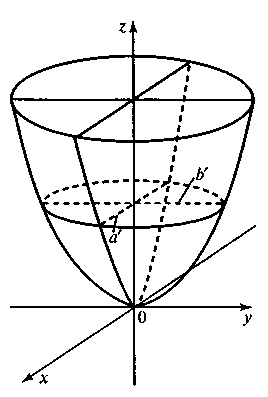

Начнём спуск с точки `(1,1)`, антиградиент в данной точке — `(-2,-2)`.

Шагая по нему, мы оказываемся в точке `(-1,-1)`.

Антиградиент в данной точке — `(2,2)`, следовательно, шагая по нему, мы вернёмся в точку `(1,1)`.

Мы зациклились.

Посмотрим на визуализацию.



In [ ]:
# @title Задача оптимизации (без шедулера)
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from ipywidgets import HBox, VBox
from IPython.display import display, clear_output
def f(x, y):
    return x**2 + y**2

def grad_f(x, y):
    return 2.0 * x, 2.0 * y

X_MIN, X_MAX = -1.2, 1.2
Y_MIN, Y_MAX = -1.2, 1.2

ELEV_DEFAULT = 5
AZIM_DEFAULT = -50

def loss_grid(x_range=(X_MIN, X_MAX), y_range=(Y_MIN, Y_MAX), steps=81):
    xs = np.linspace(x_range[0], x_range[1], steps)
    ys = np.linspace(y_range[0], y_range[1], steps)
    Xg, Yg = np.meshgrid(xs, ys)
    Z = f(Xg, Yg)
    return xs, ys, Xg, Yg, Z

xs, ys, Xg, Yg, Z = loss_grid(x_range=(X_MIN, X_MAX), y_range=(Y_MIN, Y_MAX), steps=120)
Zmin, Zmax = float(Z.min()), float(Z.max())

# =========================
# State / history
# =========================
state = {"x": 1.0, "y": 1.0, "path": [(1.0, 1.0)]}
history = [(state["x"], state["y"], float(f(state["x"], state["y"])))]
losses = [history[0][2]]

# =========================
# Widgets
# =========================
x_slider = widgets.FloatSlider(value=1.0, min=X_MIN, max=X_MAX, step=0.05, description="x", continuous_update=False)
y_slider = widgets.FloatSlider(value=1.0, min=Y_MIN, max=Y_MAX, step=0.05, description="y", continuous_update=False)

lr_slider = widgets.FloatLogSlider(value=1.0, base=10, min=-3, max=0, step=0.05, description="lr")

step_btn = widgets.Button(description="Сделать 1 шаг GD", button_style="primary")
reset_btn = widgets.Button(description="Сброс", button_style="warning")

out = widgets.Output()

def draw(x, y, lr):
    with out:
        clear_output(wait=True)

        loss = float(f(x, y))
        dx, dy = grad_f(x, y)

        fig = plt.figure(figsize=(12, 6))
        ax1 = fig.add_subplot(1, 2, 1)
        ax2 = fig.add_subplot(1, 2, 2, projection="3d")

        vmin, vmax = Zmin, Zmax

        # ========== AX1: 2D-контуры ==========
        ax1.contourf(Xg, Yg, Z, cmap="viridis", vmin=vmin, vmax=vmax, levels=30, zorder=20)
        ax1.contour(Xg, Yg, Z, colors="black", alpha=0.3, levels=30, zorder=30)

        ax1.set_xlim(X_MIN, X_MAX)
        ax1.set_ylim(Y_MIN, Y_MAX)

        xs_path = [h[0] for h in history]
        ys_path = [h[1] for h in history]
        ax1.plot(xs_path, ys_path, color="orange", zorder=110)
        ax1.scatter([x], [y], s=80, marker="o", color="tab:orange", zorder=120)

        ax1.set_title("f(x,y)=x²+y² (2D контуры)")
        ax1.set_xlabel("x")
        ax1.set_ylabel("y", labelpad=-7)

        ax1.arrow(x, y, -dx, -dy, head_width=0.06, color="black", alpha=0.25,
                  length_includes_head=True, zorder=98)
        ax1.arrow(x, y, -lr * dx, -lr * dy, head_width=0.06,
                  length_includes_head=True, zorder=99)

        # ========== AX2: 3D-поверхность ==========
        ax2.view_init(elev=ELEV_DEFAULT, azim=AZIM_DEFAULT)

        stride = 4
        Xd, Yd, Zd = Xg[::stride, ::stride], Yg[::stride, ::stride], Z[::stride, ::stride]

        ax2.plot_surface(
            Xd, Yd, Zd,
            rstride=1, cstride=1,
            linewidth=0.2, edgecolor="black",
            cmap="viridis", vmin=vmin, vmax=vmax,
            antialiased=True, alpha=0.85
        )

        ax2.set_title("3D поверхность f(x,y)=x²+y²")
        ax2.set_xlabel("x", labelpad=-15)
        ax2.set_ylabel("y", labelpad=-15)
        ax2.set_zlabel("f")

        ax2.set_xlim(X_MIN, X_MAX)
        ax2.set_ylim(Y_MIN, Y_MAX)

        zs_path = [h[2] for h in history]
        ax2.plot(xs_path, ys_path, zs_path, color="orange", linewidth=2)

        # Проекция на плоскость
        ax2.plot([x, x], [y, y], [0, loss], "k--", alpha=0.4)

        step_dx = -lr * float(dx)
        step_dy = -lr * float(dy)
        x2 = float(np.clip(x + step_dx, X_MIN, X_MAX))
        y2 = float(np.clip(y + step_dy, Y_MIN, Y_MAX))

        ax2.quiver(
            x, y, 0.0,
            x2 - x, y2 - y, 0.0,
            color="black",
            length=1.0,
            normalize=True
        )

        # Текущая точка — поверх всего
        eps = 0.1


        z_point = loss + eps

        ax2.scatter([x], [y], [z_point], s=140, c=["tab:orange"],
                    edgecolors=["black"], linewidths=1.0)

        ax2.set_zlim(0.0, vmax * 1.05)

        plt.tight_layout()
        plt.show()

def sync_from_sliders(_=None):
    state["x"] = x_slider.value
    state["y"] = y_slider.value
    draw(state["x"], state["y"], lr_slider.value)

def on_step(_):
    global losses, history

    for s in (x_slider, y_slider):
        s.unobserve_all()

    x = float(x_slider.value)
    y = float(y_slider.value)
    lr = float(lr_slider.value)

    dx, dy = grad_f(x, y)
    x_new = float(np.clip(x - lr * dx, X_MIN, X_MAX))
    y_new = float(np.clip(y - lr * dy, Y_MIN, Y_MAX))

    loss_new = float(f(x_new, y_new))
    losses.append(loss_new)
    history.append((x_new, y_new, loss_new))
    state["path"].append((x_new, y_new))

    x_slider.value = x_new
    y_slider.value = y_new

    for s in (x_slider, y_slider):
        s.observe(sync_from_sliders, names="value")

    draw(x_new, y_new, lr)

def on_reset(_):
    global losses, history

    for s in (x_slider, y_slider):
        s.unobserve_all()

    x0, y0 = 1.0, 1.0
    x_slider.value = x0
    y_slider.value = y0

    state["path"] = [(x0, y0)]
    loss0 = float(f(x0, y0))
    losses = [loss0]
    history = [(x0, y0, loss0)]

    for s in (x_slider, y_slider):
        s.observe(sync_from_sliders, names="value")

    draw(x0, y0, lr_slider.value)

for s in (x_slider, y_slider, lr_slider):
    s.observe(sync_from_sliders, names="value")

step_btn.on_click(on_step)
reset_btn.on_click(on_reset)

ui = VBox([
    HBox([x_slider, y_slider, lr_slider]),
    HBox([step_btn, reset_btn]),
    out
])

display(ui)
sync_from_sliders()


Попробуем изменять параметр `lr` в процессе обучения.

Такой подход позволит сначала делать более крупные шаги и быстро приблизиться к области минимума, а затем уменьшать `lr` и аккуратно уточнять решение.

Это особенно важно:
- в начале обучения, когда мы далеко от минимума и допустимы большие шаги;
- на финальных этапах, когда мы уже близко к минимуму и нужен аккуратный шаг, чтобы избежать отклонений от него.


#### Популярные варианты шедулеров
- **Step decay**: каждые `K` шагов уменьшаем `lr` в несколько раз.
- **Exponential decay**: `lr` убывает экспоненциально.
- **Cosine annealing**: `lr` плавно падает по косинусу от максимума к минимуму.
- **Волнообразный**: сначала опускаемся, потом немного поднимаемся, потом опускаемся ниже и опять немного приподнимаемся.


Попробуем применить шедулирование `eponential decay`. Каждый шаг будем умножать темп обучения на `0.9`.

In [ ]:
# @title Задача оптимизации (экспоненциальное уменьшение LR)
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from ipywidgets import HBox, VBox
from IPython.display import display, clear_output
def f(x, y):
    return x**2 + y**2

def grad_f(x, y):
    return 2.0 * x, 2.0 * y

X_MIN, X_MAX = -1.2, 1.2
Y_MIN, Y_MAX = -1.2, 1.2

ELEV_DEFAULT = 5
AZIM_DEFAULT = -50

def loss_grid(x_range=(X_MIN, X_MAX), y_range=(Y_MIN, Y_MAX), steps=81):
    xs = np.linspace(x_range[0], x_range[1], steps)
    ys = np.linspace(y_range[0], y_range[1], steps)
    Xg, Yg = np.meshgrid(xs, ys)
    Z = f(Xg, Yg)
    return xs, ys, Xg, Yg, Z

xs, ys, Xg, Yg, Z = loss_grid(x_range=(X_MIN, X_MAX), y_range=(Y_MIN, Y_MAX), steps=120)
Zmin, Zmax = float(Z.min()), float(Z.max())

# =========================
# State / history
# =========================
state = {"x": 1.0, "y": 1.0, "path": [(1.0, 1.0)]}
history = [(state["x"], state["y"], float(f(state["x"], state["y"])))]
losses = [history[0][2]]

# =========================
# Widgets
# =========================
x_slider = widgets.FloatSlider(value=1.0, min=X_MIN, max=X_MAX, step=0.05, description="x", continuous_update=False)
y_slider = widgets.FloatSlider(value=1.0, min=Y_MIN, max=Y_MAX, step=0.05, description="y", continuous_update=False)

lr_slider = widgets.FloatLogSlider(value=1.0, base=10, min=-3, max=0, step=0.05, description="lr")

step_btn = widgets.Button(description="Сделать 1 шаг GD", button_style="primary")
reset_btn = widgets.Button(description="Сброс", button_style="warning")

out = widgets.Output()

def draw(x, y, lr):
    with out:
        clear_output(wait=True)

        loss = float(f(x, y))
        dx, dy = grad_f(x, y)

        fig = plt.figure(figsize=(12, 6))
        ax1 = fig.add_subplot(1, 2, 1)
        ax2 = fig.add_subplot(1, 2, 2, projection="3d")

        vmin, vmax = Zmin, Zmax

        # ========== AX1: 2D-контуры ==========
        ax1.contourf(Xg, Yg, Z, cmap="viridis", vmin=vmin, vmax=vmax, levels=30, zorder=20)
        ax1.contour(Xg, Yg, Z, colors="black", alpha=0.3, levels=30, zorder=30)

        ax1.set_xlim(X_MIN, X_MAX)
        ax1.set_ylim(Y_MIN, Y_MAX)

        xs_path = [h[0] for h in history]
        ys_path = [h[1] for h in history]
        ax1.plot(xs_path, ys_path, color="orange", zorder=110)
        ax1.scatter([x], [y], s=80, marker="o", color="tab:orange", zorder=120)

        ax1.set_title("f(x,y)=x²+y² (2D контуры)")
        ax1.set_xlabel("x")
        ax1.set_ylabel("y", labelpad=-7)

        ax1.arrow(x, y, -dx, -dy, head_width=0.06, color="black", alpha=0.25,
                  length_includes_head=True, zorder=98)
        ax1.arrow(x, y, -lr * dx, -lr * dy, head_width=0.06,
                  length_includes_head=True, zorder=99)

        # ========== AX2: 3D-поверхность ==========
        ax2.view_init(elev=ELEV_DEFAULT, azim=AZIM_DEFAULT)

        stride = 4
        Xd, Yd, Zd = Xg[::stride, ::stride], Yg[::stride, ::stride], Z[::stride, ::stride]

        ax2.plot_surface(
            Xd, Yd, Zd,
            rstride=1, cstride=1,
            linewidth=0.2, edgecolor="black",
            cmap="viridis", vmin=vmin, vmax=vmax,
            antialiased=True, alpha=0.85
        )

        ax2.set_title("3D поверхность f(x,y)=x²+y²")
        ax2.set_xlabel("x", labelpad=-15)
        ax2.set_ylabel("y", labelpad=-15)
        ax2.set_zlabel("f")

        ax2.set_xlim(X_MIN, X_MAX)
        ax2.set_ylim(Y_MIN, Y_MAX)

        zs_path = [h[2] for h in history]
        ax2.plot(xs_path, ys_path, zs_path, color="orange", linewidth=2)

        # Проекция на плоскость
        ax2.plot([x, x], [y, y], [0, loss], "k--", alpha=0.4)

        step_dx = -lr * float(dx)
        step_dy = -lr * float(dy)
        x2 = float(np.clip(x + step_dx, X_MIN, X_MAX))
        y2 = float(np.clip(y + step_dy, Y_MIN, Y_MAX))

        ax2.quiver(
            x, y, 0.0,
            x2 - x, y2 - y, 0.0,
            color="black",
            length=1.0,
            normalize=True
        )

        # Текущая точка — поверх всего
        eps = 0.1


        z_point = loss + eps

        ax2.scatter([x], [y], [z_point], s=140, c=["tab:orange"],
                    edgecolors=["black"], linewidths=1.0)

        ax2.set_zlim(0.0, vmax * 1.05)

        plt.tight_layout()
        plt.show()

def sync_from_sliders(_=None):
    state["x"] = x_slider.value
    state["y"] = y_slider.value
    draw(state["x"], state["y"], lr_slider.value)

def on_step(_):
    global losses, history

    for s in (x_slider, y_slider):
        s.unobserve_all()

    x = float(x_slider.value)
    y = float(y_slider.value)
    lr = float(lr_slider.value)

    dx, dy = grad_f(x, y)
    x_new = float(np.clip(x - lr * dx, X_MIN, X_MAX))
    y_new = float(np.clip(y - lr * dy, Y_MIN, Y_MAX))

    loss_new = float(f(x_new, y_new))
    losses.append(loss_new)
    history.append((x_new, y_new, loss_new))
    state["path"].append((x_new, y_new))

    x_slider.value = x_new
    y_slider.value = y_new


    for s in (x_slider, y_slider):
        s.observe(sync_from_sliders, names="value")

    draw(x_new, y_new, lr)
    lr_slider.value *= 0.9

def on_reset(_):
    global losses, history

    for s in (x_slider, y_slider):
        s.unobserve_all()

    x0, y0 = 1.0, 1.0
    x_slider.value = x0
    y_slider.value = y0

    state["path"] = [(x0, y0)]
    loss0 = float(f(x0, y0))
    losses = [loss0]
    history = [(x0, y0, loss0)]

    for s in (x_slider, y_slider):
        s.observe(sync_from_sliders, names="value")

    draw(x0, y0, lr_slider.value)

for s in (x_slider, y_slider, lr_slider):
    s.observe(sync_from_sliders, names="value")

step_btn.on_click(on_step)
reset_btn.on_click(on_reset)

ui = VBox([
    HBox([x_slider, y_slider, lr_slider]),
    HBox([step_btn, reset_btn]),
    out
])

display(ui)
sync_from_sliders()


Благодаря удачно подобранному шедулеру мы решили проблему большого `lr` и смогли прийти в точку минимума, делая всё более и более аккуратные шаги.

### Задание 6



Всегда ли нахождение точки минимума подразумевает наилучшее решение задачи?

#### ОТВЕТ ДЛЯ СЕМИНАРИСТА

Нет, и этому есть две причины:

1) Локальность минимума (существует решение лучше)
2) Подстраивание под обучающую выборку и потеря обучающей способности

## Переобучение



Повторим определение.

> **Переобучение** — это когда модель слишком сильно подстраивается под обучающую выборку, не выучивая никакого правила и не приобретая обобщающую способность.

Линейная модель устойчива к переобучению из-за того, что она очень простая. У неё нет большого числа параметров, поэтому ей сложно «заучить» данные.

Но есть возможность помочь ей переобучиться.

In [ ]:
# Создание датасета с признаками X и X^2
data = pd.DataFrame({
    'X': X,
    'X_squared': X**2,
    'y': y
})

Обучим линейную регрессию на нашем наборе данных и нарисуем её график.

In [ ]:
# @title Полиномиальная линейная регрессия (d=2)
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import ipywidgets as widgets
from ipywidgets import HBox, VBox
from IPython.display import display, clear_output

def mse_loss(Xmat, yvec, w1, w2, b):
    yhat = w1 * Xmat[:, 0] + w2 * Xmat[:, 1] + b
    return float(np.mean((yhat - yvec) ** 2))

lr_slider = widgets.FloatLogSlider(value=0.08, base=10, min=-3, max=0, step=0.05, description="lr")
steps_slider = widgets.IntSlider(value=60, min=5, max=300, step=5, description="max steps")

w1_slider = widgets.FloatSlider(value=-3.0, min=-3, max=3, step=0.05, description="w1", continuous_update=False)
w2_slider = widgets.FloatSlider(value=-3.0, min=-3, max=3, step=0.05, description="w2", continuous_update=False)
b_slider = widgets.FloatSlider(value=-3.0, min=-3, max=3, step=0.05, description="b", continuous_update=False)

step_btn = widgets.Button(description="Сделать 1 шаг GD", button_style="primary")
reset_btn = widgets.Button(description="Сброс", button_style="warning")

out = widgets.Output()

POINT_COLOR = "tab:orange"

w1_default = -3.0
w2_default = -3.0
b_default = -3.0

Xmat = data[["X", "X_squared"]].values
yvec = data["y"].values
loss_default = mse_loss(Xmat, yvec, w1_default, w2_default, b_default)

sim = {
    "w1": -3.0,   # Вес для X
    "w2": -3.0,   # Вес для X^2
    "b": -3.0,    # Смещение
    "t": 0,
    "traj": None,       # np.array shape (t+1, 3)
    "settings": None,    # (lr, max_steps)
    "loss_history": [loss_default]
}

def _get_settings():
    lr = float(lr_slider.value)
    max_steps = int(steps_slider.value)
    return lr, max_steps

def reset_sim():
    lr, max_steps = _get_settings()
    w0 = float(w1_slider.value)
    b0 = float(b_slider.value)

    sim["w1"] = w0
    sim["w2"] = w0  # Симметрично на старте
    sim["b"]  = b0
    sim["t"]  = 0
    sim["traj"] = np.array([[w0, w0, b0]], dtype=float)
    sim["settings"] = (lr, max_steps)
    sim["loss_history"] = [loss_default]

def grad_mse_batch(Xb, yb, w1, w2, b):
    # yhat = w1 * X + w2 * X^2 + b
    yhat = w1 * Xb[:, 0] + w2 * Xb[:, 1] + b
    err = yhat - yb

    dw1 = 2 * np.mean(err * Xb[:, 0])
    dw2 = 2 * np.mean(err * Xb[:, 1])
    db  = 2 * np.mean(err)
    return float(dw1), float(dw2), float(db)

def step_once():
    lr, max_steps = _get_settings()
    sim["settings"] = (lr, max_steps)

    if sim["t"] >= max_steps:
        return

    w1, w2, b = float(sim["w1"]), float(sim["w2"]), float(sim["b"])

    Xb = data[["X", "X_squared"]].values
    yb = data["y"].values

    dw1, dw2, db = grad_mse_batch(Xb, yb, w1, w2, b)

    sim["w1"] = float(w1 - lr * dw1)
    sim["w2"] = float(w2 - lr * dw2)
    sim["b"]  = float(b  - lr * db)

    sim["t"] += 1
    sim["traj"] = np.vstack([sim["traj"], [sim["w1"], sim["w2"], sim["b"]]])
    sim["loss_history"].append(mse_loss(Xmat, yvec, sim["w1"], sim["w2"], sim["b"]))

def predict(x, w1, w2, b):
    return w1 * x + w2 * (x**2) + b

def draw_current():
    lr, max_steps = sim["settings"]
    t = sim["t"]
    w1, w2, b = float(sim["w1"]), float(sim["w2"]), float(sim["b"])

    Xmat = data[["X", "X_squared"]].values
    yvec = data["y"].values
    loss = mse_loss(Xmat, yvec, w1, w2, b)

    with out:
        clear_output(wait=True)

        fig, ax = plt.subplots(1, 2, figsize=(14, 6))

        vmin=0
        vmax=100

        #=====[AX0]=============================================================

        losses = sim["loss_history"]
        x_losses = np.arange(1, len(losses) + 1)


        points = np.array([x_losses, losses]).T.reshape(-1, 1, 2)
        if len(points) >= 2:
            segments = np.concatenate([points[:-1], points[1:]], axis=1)
            lc = LineCollection(segments, cmap="viridis")
            lc.set_clim(vmin=vmin, vmax=vmax)
            lc.set_array(np.array(losses[:-1], dtype=float))
            lc.set_linewidth(2)
            ax[0].add_collection(lc)

        ax[0].scatter(x_losses, losses, c=losses, cmap="viridis",
                    vmin=vmin, vmax=vmax, s=50, zorder=20)
        ax[0].set_xlim(0, max(len(losses) + 1, 11))
        ax[0].set_ylim(0, 130)
        ax[0].set_xticks(list(range(1, max(len(losses) + 1, 11))))
        ax[0].grid(True)
        ax[0].set_title(f"Значение функции потерь (MSE)")

        #=====[AX1]=============================================================

        ax[1].scatter(data["X"], data["y"], s=35, label="data", color=POINT_COLOR)

        xs = np.linspace(data["X"].min(), data["X"].max(), 200)
        ax[1].plot(xs, predict(xs, w1, w2, b), linewidth=2, label="model")

        ax[1].set_title(f"Решение модели")
        ax[1].set_xlabel("X")
        ax[1].set_ylabel("y")
        ax[1].set_xlim(-2, 2)
        ax[1].set_ylim(-10, 10)
        ax[1].grid(True)
        ax[1].legend()

        plt.tight_layout()
        plt.show()


def on_reset(_):
    reset_sim()
    draw_current()

def on_step(_):
    step_once()
    draw_current()

def on_params_change(_=None):
    sim["loss_history"].append(mse_loss(Xmat, yvec, sim["w1"], sim["w2"], sim["b"]))
    sim["w1"] = w1_slider.value
    sim["w2"] = w2_slider.value
    sim["b"]  = b_slider.value
    draw_current()

# listeners
step_btn.on_click(on_step)
reset_btn.on_click(on_reset)

for w in (lr_slider, steps_slider, w1_slider, w2_slider, b_slider):
    w.observe(on_params_change, names="value")

# init
reset_sim()

ui = VBox([
    HBox([lr_slider, steps_slider]),
    HBox([w1_slider, w2_slider,  b_slider]),
    HBox([step_btn, reset_btn]),
    out
])

display(ui)
draw_current()



Вроде бы всё свелось к обычной линии, только чуть изогнутой. Однако возникает вопрос, не придём ли мы к тому же эффекту, если продолжим добавлять полиномиальные признаки.



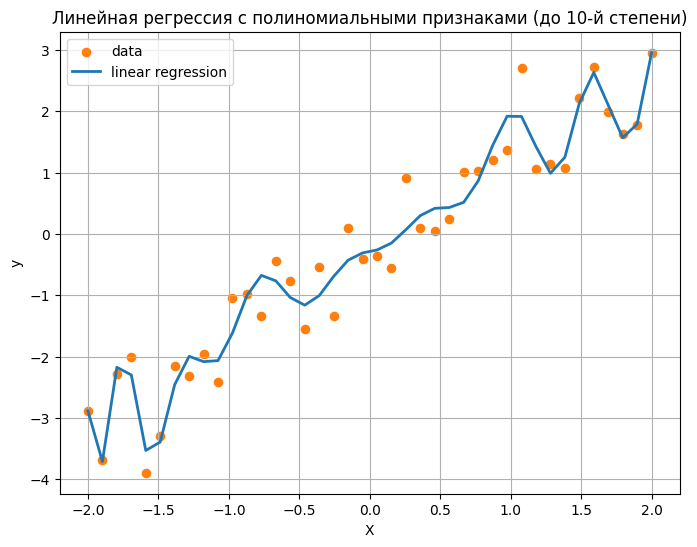

In [ ]:
# @title Полиномиальная линейная регрессия (d=10)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
import ipywidgets as widgets
from IPython.display import display, clear_output


# Преобразуем X в DataFrame
data = pd.DataFrame({
    'X': X,
    'y': y
})

# Создаём признаки до 20-й степени
poly = PolynomialFeatures(degree=20)
X_poly = poly.fit_transform(X.reshape(-1, 1))

# Создаём и обучаем модель линейной регрессии
model = LinearRegression()
model.fit(X_poly, y)

# Отображаем модель и данные
def draw_model():
    # Получаем предсказания модели
    y_pred = model.predict(X_poly)

    # Построение графика
    fig, ax = plt.subplots(figsize=(8, 6))
    ax.scatter(X, y, s=35, label="data", color="tab:orange")  # Реальные точки
    ax.plot(X, y_pred, linewidth=2, label="linear regression", color="tab:blue")  # Линия модели
    ax.set_title("Линейная регрессия с полиномиальными признаками (до 10-й степени)")
    ax.set_xlabel("X")
    ax.set_ylabel("y")
    ax.grid(True)
    ax.legend()
    plt.show()

# Запускаем начальный график
draw_model()


А вот теперь получилась совсем непрямая линия.

### Задание 7



Чем можно объяснить такое поведение?

#### ОТВЕТ ДЛЯ СЕМИНАРИСТА

Многочлен большой степени может идеально проходить через все точки обучающей выборки, но такая модель практически не способна к обобщению.

## Улучшение моделей: подбор гиперпараметров

Один из способов контролировать сложность модели — настройка её гиперпараметров.


Вспомним датасет, который мы уже разбирали.

In [ ]:
# Уже знакомый нам датасет
!gdown 1yd50FxrKOwUGt_QaZqDjwwNaeTkMRcKW

* `age` — возраст клиента;
* `sex` — пол клиента;
* `bmi` — индекс массы тела клиента (соотношение веса и роста);
* `children` — количество детей у клиента;
* `smoker` — курит ли клиент;
* `region` — регион проживания клиента;
* `charges` — стоимость страховых услуг;
* `charges_euro` — стоимость страховых услуг, пересчитанная в евро (по курсу, на момент выплат).

In [ ]:
# Импортируем Pandas и NumPy
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

# Считываем датасет
df = pd.read_csv('/content/insurance_mod.csv')

In [ ]:
# Выбираем категориальные переменные и применяем One-Hot Encoding
df_encoded = pd.get_dummies(df, columns=['sex', 'smoker', 'region'], drop_first=True)

df_encoded = df_encoded.drop("charges_euro", axis = 1)
display(df_encoded)

На прошлом семинаре мы обучили несколько моделей машинного обучения и получили какие-то метрики.

Вспомним, что мы успели создать для решения задачи регрессии:

- линейную регрессию,
- решающее дерево,
- случайный лес.


Теперь разделим датасет на обучающую, тестовую и валидационные выборки.

Помним, что целевая переменная — `"charges"`.



In [ ]:
# Определение признаков (X) и целевой переменной (y)
X = df_encoded.drop('charges', axis=1)
y = df_encoded['charges']

# Разделение данных на обучающую (train) и временную (test_val) выборки
X_train, X_test_val, y_train, y_test_val = train_test_split(X, y,
                                                          train_size=0.7, # 70% для обучения
                                                          random_state=112,
                                                          stratify=X['sex_male'])

# Разделение временной выборки на тестовую (test) и валидационную (val) выборки
X_test, X_val, y_test, y_val = train_test_split(X_test_val, y_test_val,
                                                  train_size=0.5, # 15% для теста, 15% для валидации (0.5 от 30%)
                                                  random_state=112,
                                                  stratify=X_test_val['sex_male'])

print(f"Размер обучающей выборки: {X_train.shape[0]} объектов")
print(f"Размер тестовой выборки: {X_test.shape[0]} объектов")
print(f"Размер валидационной выборки: {X_val.shape[0]} объектов")

На лекции мы изучили подбор гиперпараметров по сетке. Теперь реализуем его на примере решающего дерева.

In [ ]:
# Импорт библиотек
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.datasets import load_iris


In [ ]:
# Данные
X, y = X_train, y_train

# Модель и сетка
model = DecisionTreeClassifier(random_state=42)

# Определяем гиперпараметры
param_grid = {
    "max_depth": [1, 2, 30, 4, 5, None],
    "min_samples_split": [2, 50, 10, 20, 50],
}


Воспользуемся встроенным в sklearn методом `GridSearchCV`.

In [ ]:
from sklearn.model_selection import GridSearchCV

tree = DecisionTreeRegressor(random_state=42)

# GridSearchCV с функцией потерь
gs = GridSearchCV(
    tree,
    param_grid,
    cv=5
)

gs.fit(X, y)

In [ ]:
results = gs.cv_results_
best_params = gs.best_params_
print(f"Лучшие параметры: {best_params}")

In [ ]:
# @title Код отрисовки результата grid search
# Берём loss (а не отрицательное значение)
loss = results["mean_test_score"]
max_depths = param_grid["max_depth"]
min_samples_splits = param_grid["min_samples_split"]


# Координаты
xpos, ypos = np.meshgrid(
    np.arange(len(max_depths)),
    np.arange(len(min_samples_splits)),
    indexing="ij"
)

xpos = xpos.ravel()
ypos = ypos.ravel()
zpos = np.zeros_like(xpos)

dx = dy = 0.7
dz = loss

# Цвета: лучший (минимальный loss) — рыжий
colors = ["tab:blue"] * len(dz)
best_idx = np.argmin(dz)
colors[best_idx] = "orange"

# График
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d")

ax.bar3d(xpos, ypos, zpos, dx, dy, dz, color=colors)

#ax.set_zscale("log")

ax.set_xticks(np.arange(len(max_depths)) + dx / 2)
ax.set_yticks(np.arange(len(min_samples_splits)) + dy / 2)
ax.set_xticklabels(max_depths)
ax.set_yticklabels(min_samples_splits)

ax.set_xlabel("max_depth")
ax.set_ylabel("min_samples_split")
# ax.set_zlabel("CV log loss (log scale)")

plt.title("Зависимость функции потерь от параметров")

# plt.tight_layout()
plt.show()


Мы нашли оптимальные гиперпараметры, теперь замерим качество модели.

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Предсказания на валидации
best_tree = gs.best_estimator_
y_val_pred = best_tree.predict(X_val)

val_rmse = (mean_squared_error(y_val, y_val_pred))**0.5
val_mae = mean_absolute_error(y_val, y_val_pred)

print(f"\nВалидация:")
print(f"RMSE: {val_rmse:.4f}")
print(f"MAE: {val_mae:.4f}")

# Предсказания на тесте
y_test_pred = best_tree.predict(X_test)
test_rmse = (mean_squared_error(y_test, y_test_pred))**0.5
test_mae = mean_absolute_error(y_test, y_test_pred)

print(f"\nТест:")
print(f"RMSE: {test_rmse:.4f}")
print(f"MAE: {test_mae:.4f}")


### Результаты

Вспомним, какие значения мы получали на прошлом семинаре при обучении дерева с какими-то параметрами:

- RMSE на обучающей выборке (Decision Tree): `4115.8521`;

- RMSE на тестовой выборке (Decision Tree): `4902.7033`.

Результат стал существенно лучше.

Однако подобранные нами гиперпараметры могут быть далеки от идеала. Мы сейчас точно не знаем, за что они отвечают, и оптимальные параметры могут находиться, например, в интервале от `20` до `30`.

Чтобы это проверить, реализуем метод случайного подбора гиперпараметров.

In [ ]:
from sklearn.model_selection import RandomizedSearchCV

# 1. Задаём пространство гиперпараметров для случайного поиска
param_distributions = {
    'max_depth': np.arange(2, 30),  # Теп
    'min_samples_split': np.arange(2, 30),
    'min_samples_leaf': np.arange(1, 30),
}

In [ ]:
# 2. Создаём базовую модель
tree = DecisionTreeRegressor(random_state=42)

In [ ]:
# 3. Настраиваем RandomizedSearchCV
random_search = RandomizedSearchCV(
    estimator=tree,
    param_distributions=param_distributions,
    n_iter=30,               # Число случайных комбинаций (можно менять)
    cv=5,                    # 5-fold кросс-валидация на train
    random_state=42,
)

In [ ]:
# 4. Запускаем поиск оптимальных параметров на обучающей выборке
random_search.fit(X_train, y_train)

In [ ]:
# 5. Выводим лучшие параметры и оценку
print("\nЛучшие параметры:", random_search.best_params_)

In [ ]:
# 6. Получаем лучшую модель
best_tree = random_search.best_estimator_

# 7. Оцениваем модель на валидационной и тестовой выборках
y_val_pred = best_tree.predict(X_val)
y_test_pred = best_tree.predict(X_test)

# 8. Вычисляем метрики
def evaluate_model(y_true, y_pred, dataset_name):
    rmse = mean_squared_error(y_true, y_pred) ** 0.5
    mae = mean_absolute_error(y_true, y_pred)
    print(f"\n{dataset_name}:")
    print(f"  RMSE:  {rmse:.4f}")
    print(f"  MAE:  {mae:.4f}")
    return {'RMSE': rmse, 'MAE': mae}

val_metrics = evaluate_model(y_val, y_val_pred, "Валидационная выборка")
test_metrics = evaluate_model(y_test, y_test_pred, "Тестовая выборка")


Случайный поиск тоже нашёл неплохое решение, однако, видимо, более качественного результата мы уже не получим.

## Бутстреп-оценка моделей

Подобранные гиперпараметры позволили получить неплохое качество. Теперь нужно выяснить, будет ли оно стабильным.

Выполним бутстреп-оценку модели.

Вспомним принцип работы бутстрепа. Мы предполагаем, что данные, которые у нас есть, достаточно репрезентативны. То есть в реальности наша модель не встретится с какими-то абсолютно новыми и уникальными объектами и зависимостями.

Поэтому выборку можно рассматривать как генеральную совокупность — то есть все возможные данные.

Соответственно, набирая из неё объекты, мы получаем новые обучающие наборы.



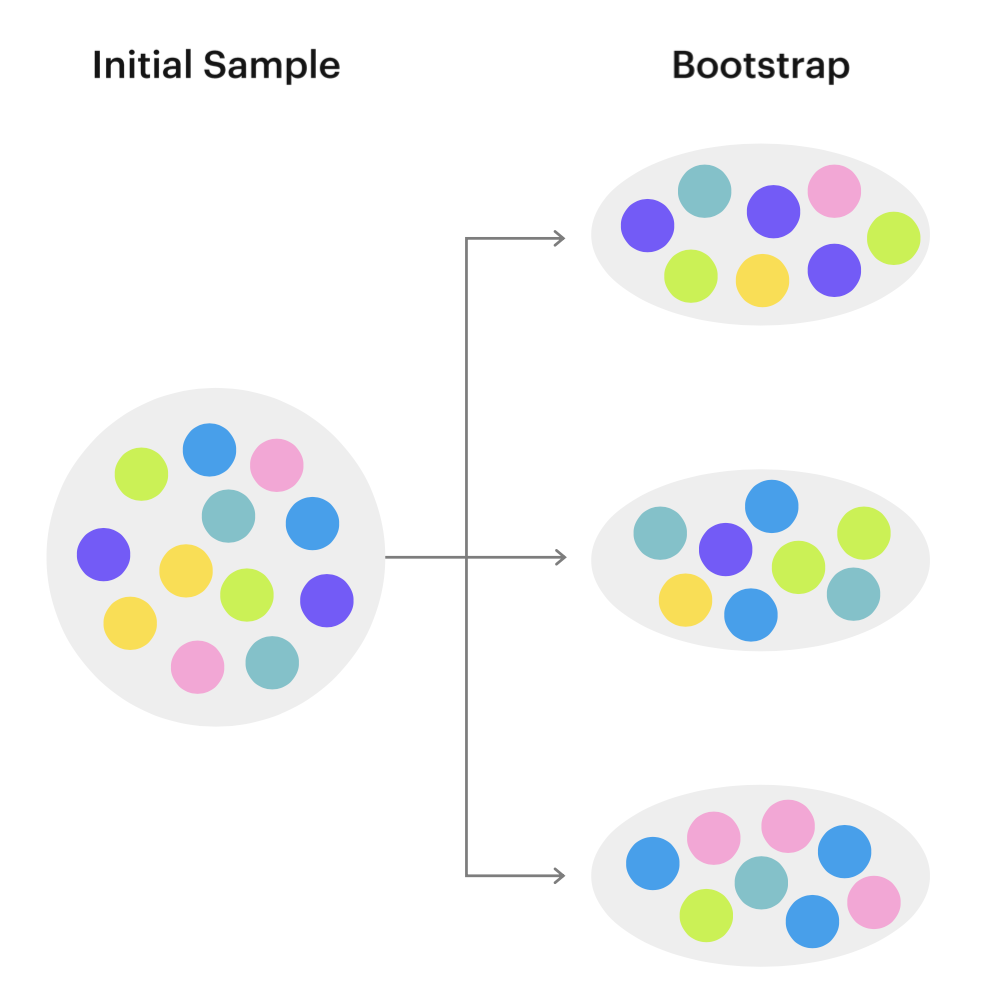

Это множество наборов — наша возможность многократно проверить модель на разных данных и построить гистограмму качества её работы при различных входных данных. Это позволит понять, насколько стабильно модель выдаёт хорошее качество и насколько сильно её «штормит» в зависимости от обучающей выборки.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
from tqdm import tqdm  # Для наглядного отображения прогресса

# Лучшие гиперпараметры, найденные ранее
best_params = {
    'max_depth': 3,
    'min_samples_leaf': 1,
    'min_samples_split': 2,
    'random_state': 42
}

# Количество бутстреп-выборок
n_bootstraps = 1000

In [ ]:
# Список для хранения значений ошибок
mse_scores = []
mae_scores = []

# Размер обучающей выборки
n_samples = X_train.shape[0]

# Бутстреп-цикл
for i in tqdm(range(n_bootstraps), desc="Bootstrap iterations"):
    # Случайная выборка с возвращением из обучающей выборки
    bootstrap_indices = np.random.choice(n_samples, size=n_samples, replace=True)
    X_boot = X_train.iloc[bootstrap_indices]
    y_boot = y_train.iloc[bootstrap_indices]

    # Обучаем модель на бутстреп-выборке
    tree = DecisionTreeRegressor(**best_params)
    tree.fit(X_boot, y_boot)

    # Предсказываем на валидационной выборке (фиксированная)
    y_pred = tree.predict(X_val)

    # Считаем ошибки
    mse = mean_squared_error(y_val, y_pred)
    mae = mean_absolute_error(y_val, y_pred)

    mse_scores.append(mse)
    mae_scores.append(mae)

mse_scores = np.array(mse_scores)
mae_scores = np.array(mae_scores)

# Выводим основные статистики
print(f"MSE: среднее = {mse_scores.mean():.2f}, std = {mse_scores.std():.2f}")
print(f"MAE: среднее = {mae_scores.mean():.2f}, std = {mae_scores.std():.2f}")


In [ ]:
# Строим гистограммы распределения ошибок
fig, axs = plt.subplots(1, 2, figsize=(14, 6))

# Гистограмма для MSE
axs[0].hist(mse_scores, bins=30, color='skyblue', edgecolor='black', alpha=0.7)
axs[0].set_title('Распределение MSE (Mean Squared Error)')
axs[0].set_xlabel('MSE')
axs[0].set_ylabel('Частота')
axs[0].axvline(mse_scores.mean(), color='red', linestyle='--', label=f'Среднее = {mse_scores.mean():.2f}')
axs[0].legend()

# Гистограмма для MAE
axs[1].hist(mae_scores, bins=30, color='lightgreen', edgecolor='black', alpha=0.7)
axs[1].set_title('Распределение MAE (Mean Absolute Error)')
axs[1].set_xlabel('MAE')
axs[1].set_ylabel('Частота')
axs[1].axvline(mae_scores.mean(), color='red', linestyle='--', label=f'Среднее = {mae_scores.mean():.2f}')
axs[1].legend()

plt.suptitle('Бутстреп-оценка ошибок модели решающего дерева', fontsize=16)
plt.show()

### Задание 8



Какой вывод можно сделать по данным графикам?

#### ОТВЕТ ДЛЯ СЕМИНАРИСТА

MAE в основном находится в интервале `2800-3100`

При работе с real-time данными модель, скорее всего, будет ошибаться в своих прогнозах на `2900`. В нашем случае это достаточно серьезный разброс для модели, что неудивительно для простой линейной регрессии.

Из этого можно сделать вывод, что оценка достаточно устойчива - точечное измерение с высокой вероятностью попадет в небольшой промежуток.

## Пайплайн машинного обучения (с учётом новой информации)

1. EDA (Exploratory Data Analysis):
   - визуализация распределений признаков;
   - анализ пропущенных значений и аномалий;
   - изучение взаимосвязей между признаками (корреляции, тепловые карты);
   - проверка гипотез о данных;
   - формулировка предположений о полезных признаках.

2. Предобработка данных:
   - очистка: удаление или заполнение пропусков, фильтрация выбросов;
   - преобразование типов данных;
   - кодирование категориальных переменных (`One‑Hot`, `Label Encoding` и другие);
   - разделение на тренировочный (`train`), валидационный (`val`) и тестовый (`test`) наборы.

3. Выбор ML‑моделей:
   - подбор нескольких алгоритмов, подходящих под задачу;
   - учёт требований к интерпретируемости, скорости, ресурсоёмкости.

4. Обучение на тренировочной выборке:
   - настройки оптимизатора (выбор алгоритма оптимизации, шедулера);
   - обнаружение переобучения по валидационной выборке.

5. Валидация на валидационной выборке:
   - замер метрик на валидационном наборе;
   - отбор лучших моделей по ключевым метрикам;
   - итеративная настройка гиперпараметров (`Grid Search`, `Random Search`).

6. Замер метрик на тестовом датасете (`test`):
   - расчёт основных метрик (`accuracy`, `precision`, `recall`, `MSE`);
   - анализ ошибок модели (матрица ошибок, примеры неверных предсказаний).

